<div style="background: white;
            padding: 15px 20px;
            border-radius: 8px;
            border-left: 6px solid #c1121f;
            font-family: 'Segoe UI', sans-serif;
            color: #1a1a1a;
            max-width: 800px;">

<h1 style="margin-bottom: 5px;">NB02: Exploratory Data Analysis</h1>

<p style="font-weight: bold; margin-top: 0;">Credit Default Prediction · IFRS 9 Provisioning Model · 2026</p>

<ul>
    <li>📅 <strong>Date:</strong> 26 August 2026</li>
    <li>🎯 <strong>Purpose:</strong> Deeply explore the German Credit dataset to understand which features are most predictive of default, identify patterns, and prepare feature engineering decisions for NB03</li>
</ul>

<p><strong>Input:</strong></p>
<ul>
    <li><code>../data/processed/german_credit_clean.csv</code> — cleaned dataset from NB01</li>
</ul>

<p><strong>Outputs:</strong></p>
<ul>
    <li><code>../data/processed/german_credit_features.csv</code> — encoded, scaled, model-ready dataset</li>
    <li><code>../figures/default_rate_by_category.png</code> — default rates across categorical features</li>
    <li><code>../figures/correlation_heatmap.png</code> — numerical feature correlations</li>
    <li><code>../figures/feature_boxplots.png</code> — numerical features by default status</li>
    <li><code>../figures/default_rate_by_age_duration.png</code> — default rate across age and duration bins</li>
</ul>

<p><strong>Key Techniques Used:</strong></p>
<ul>
    <li>Default rate analysis by category</li>
    <li>Correlation heatmap for numerical features</li>
    <li>Boxplots comparing defaulted vs repaid distributions</li>
    <li>Binned default rate analysis for age and duration</li>
    <li>One-hot encoding for categorical features</li>
    <li>Feature scaling for numerical features</li>
</ul>

<p><strong>Workflow:</strong> Load → Numerical Analysis → Categorical Analysis → Correlation → Feature Engineering → Save</p>

</div>

## ⚙️ Importing Libraries

In [1]:
# Standard data manipulation and visualisation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")
plt.style.use("dark_background")
sns.set_palette("coolwarm")

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 📂 Section 1: Load Data

### 📍 Load Cleaned Dataset from NB01

In [2]:
# Load the cleaned dataset saved at the end of NB01
# This has renamed columns and a binary target (0=repaid, 1=defaulted)
df = pd.read_csv("../data/processed/german_credit_clean.csv")

print(f"✅ Data loaded")
print(f"📐 Shape   : {df.shape}")
print(f"🎯 Defaults: {df['target'].sum()} ({df['target'].mean()*100:.1f}%)")
df.head()

✅ Data loaded
📐 Shape   : (1000, 21)
🎯 Defaults: 300 (30.0%)


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installments,housing,existing_credits,job,dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


## 📊 Section 2: Numerical Feature Analysis

### 📍 Step 1: Boxplots — Numerical Features by Default Status

Boxplots are ideal here because they show the full distribution — median, interquartile range, and outliers — split by default status. This lets us immediately see whether defaulters and non-defaulters have meaningfully different distributions for each numerical feature, which is a direct signal of predictive power before any modelling. A feature where the two boxes barely overlap is a strong candidate predictor. A feature where the boxes are almost identical is unlikely to help the model much on its own.

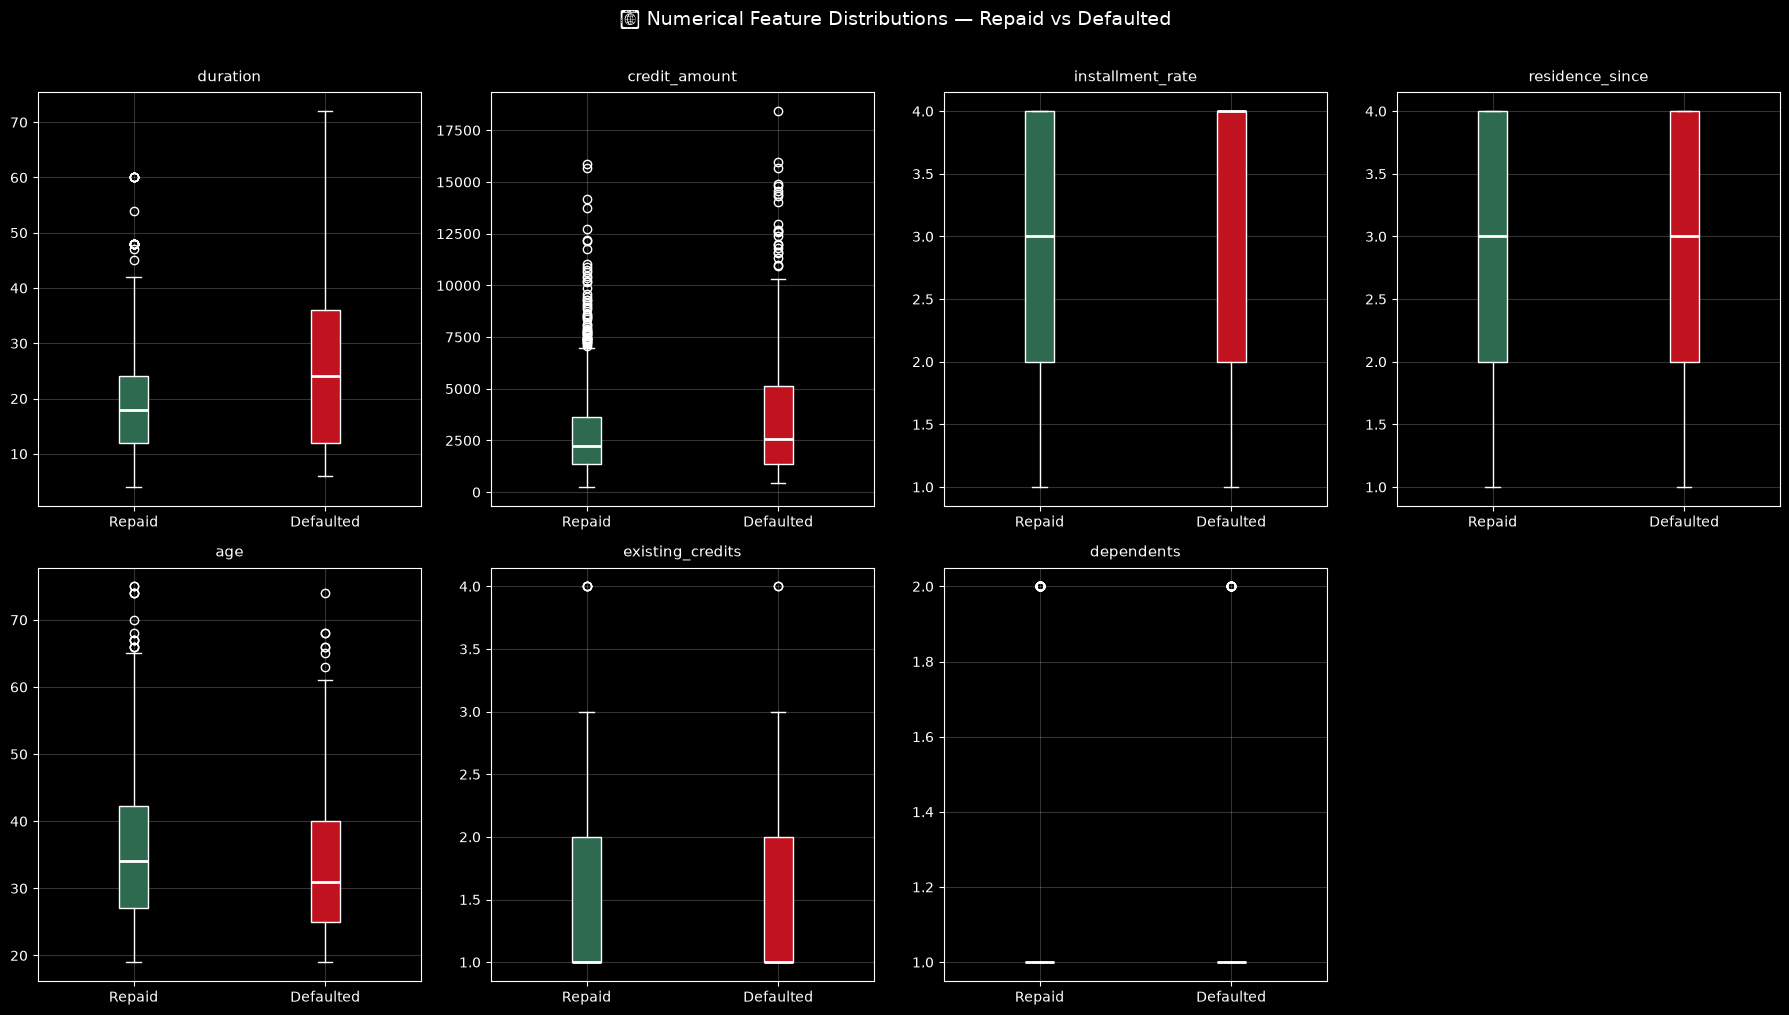

💾 Saved to ../figures/feature_boxplots.png


In [4]:
numerical_cols = [
    "duration", "credit_amount", "installment_rate",
    "residence_since", "age", "existing_credits", "dependents"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    # Split data into repaid and defaulted groups
    data_repaid    = df[df["target"]==0][col]
    data_defaulted = df[df["target"]==1][col]

    # Draw boxplot with custom patch colours
    bp = axes[i].boxplot(
        [data_repaid, data_defaulted],
        patch_artist=True,
        tick_labels=["Repaid", "Defaulted"],
        medianprops=dict(color="white", linewidth=2)
    )

    # Green for repaid, red for defaulted
    bp["boxes"][0].set_facecolor("#2d6a4f")
    bp["boxes"][1].set_facecolor("#c1121f")

    axes[i].set_title(col, fontsize=11, pad=8)
    axes[i].grid(alpha=0.2)

axes[-1].set_visible(False)
fig.suptitle("📊 Numerical Feature Distributions — Repaid vs Defaulted",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../figures/feature_boxplots.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/feature_boxplots.png")

### 📍 Step 2: Correlation Heatmap

We examine correlations between numerical features for two reasons. First, to identify which features are most correlated with the target — a direct signal of predictive power. Second, to check for multicollinearity between features — if two features are highly correlated with each other they carry redundant information, which can destabilise logistic regression coefficients in NB03. A rule of thumb is that correlations above 0.7 between predictors warrant attention.

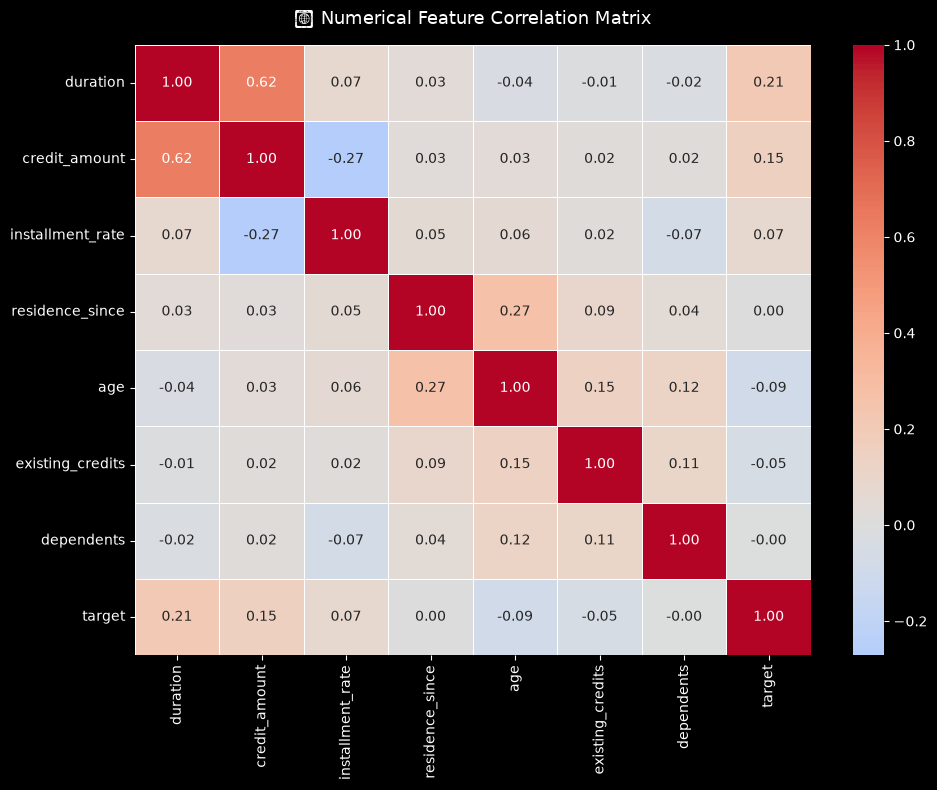

💾 Saved to ../figures/correlation_heatmap.png


In [5]:
# Include target in the correlation matrix so we can see
# which features are most linearly associated with default
corr = df[numerical_cols + ["target"]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("🔗 Numerical Feature Correlation Matrix",
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("../figures/correlation_heatmap.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/correlation_heatmap.png")

### 📍 Step 3: Binned Default Rate — Age and Duration

Rather than looking at raw distributions, we bin age and duration into meaningful ranges and calculate the default rate within each bin. This reveals non-linear relationships — for example whether default risk drops smoothly with age or jumps sharply at a specific threshold.
Non-linear relationships like this are exactly what XGBoost captures that logistic regression misses, which is why identifying them here helps frame the model comparison in NB03 and NB04.

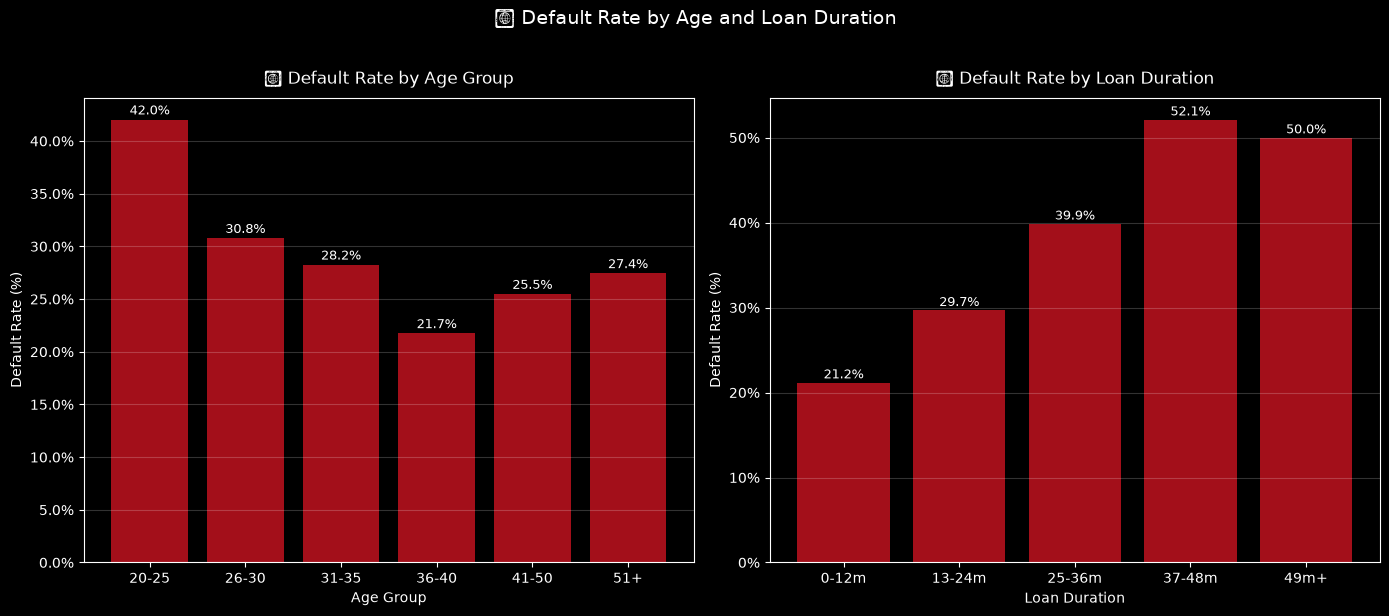

💾 Saved to ../figures/default_rate_by_age_duration.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Age bins — group borrowers into career stage buckets
df["age_bin"] = pd.cut(df["age"],
                        bins=[19, 25, 30, 35, 40, 50, 75],
                        labels=["20-25", "26-30", "31-35",
                                "36-40", "41-50", "51+"])

age_default = df.groupby("age_bin", observed=True)["target"].mean() * 100

axes[0].bar(age_default.index, age_default.values,
            color="#c1121f", alpha=0.85, edgecolor="none")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_title("📉 Default Rate by Age Group", fontsize=12, pad=10)
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Default Rate (%)")
axes[0].grid(alpha=0.2, axis="y")

# Add value labels on each bar
for i, v in enumerate(age_default.values):
    axes[0].text(i, v + 0.5, f"{v:.1f}%",
                 ha="center", fontsize=9, color="white")

# Duration bins — group loans by repayment period
df["duration_bin"] = pd.cut(df["duration"],
                             bins=[0, 12, 24, 36, 48, 72],
                             labels=["0-12m", "13-24m", "25-36m",
                                     "37-48m", "49m+"])

dur_default = df.groupby("duration_bin", observed=True)["target"].mean() * 100

axes[1].bar(dur_default.index, dur_default.values,
            color="#c1121f", alpha=0.85, edgecolor="none")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("📉 Default Rate by Loan Duration", fontsize=12, pad=10)
axes[1].set_xlabel("Loan Duration")
axes[1].set_ylabel("Default Rate (%)")
axes[1].grid(alpha=0.2, axis="y")

for i, v in enumerate(dur_default.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%",
                 ha="center", fontsize=9, color="white")

plt.suptitle("📊 Default Rate by Age and Loan Duration",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../figures/default_rate_by_age_duration.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/default_rate_by_age_duration.png")

## 🏷️ Section 3: Categorical Feature Analysis

### 📍 Default Rate by Categorical Feature

For categorical features, the most informative analysis is the default
rate within each category — not just the count of observations. A
category might have very few observations but an extremely high default
rate, making it a strong risk signal. Conversely a common category
with a low default rate is a strong positive signal. The dashed cyan
line marks the overall 30% average default rate — bars above it
represent above-average risk categories.

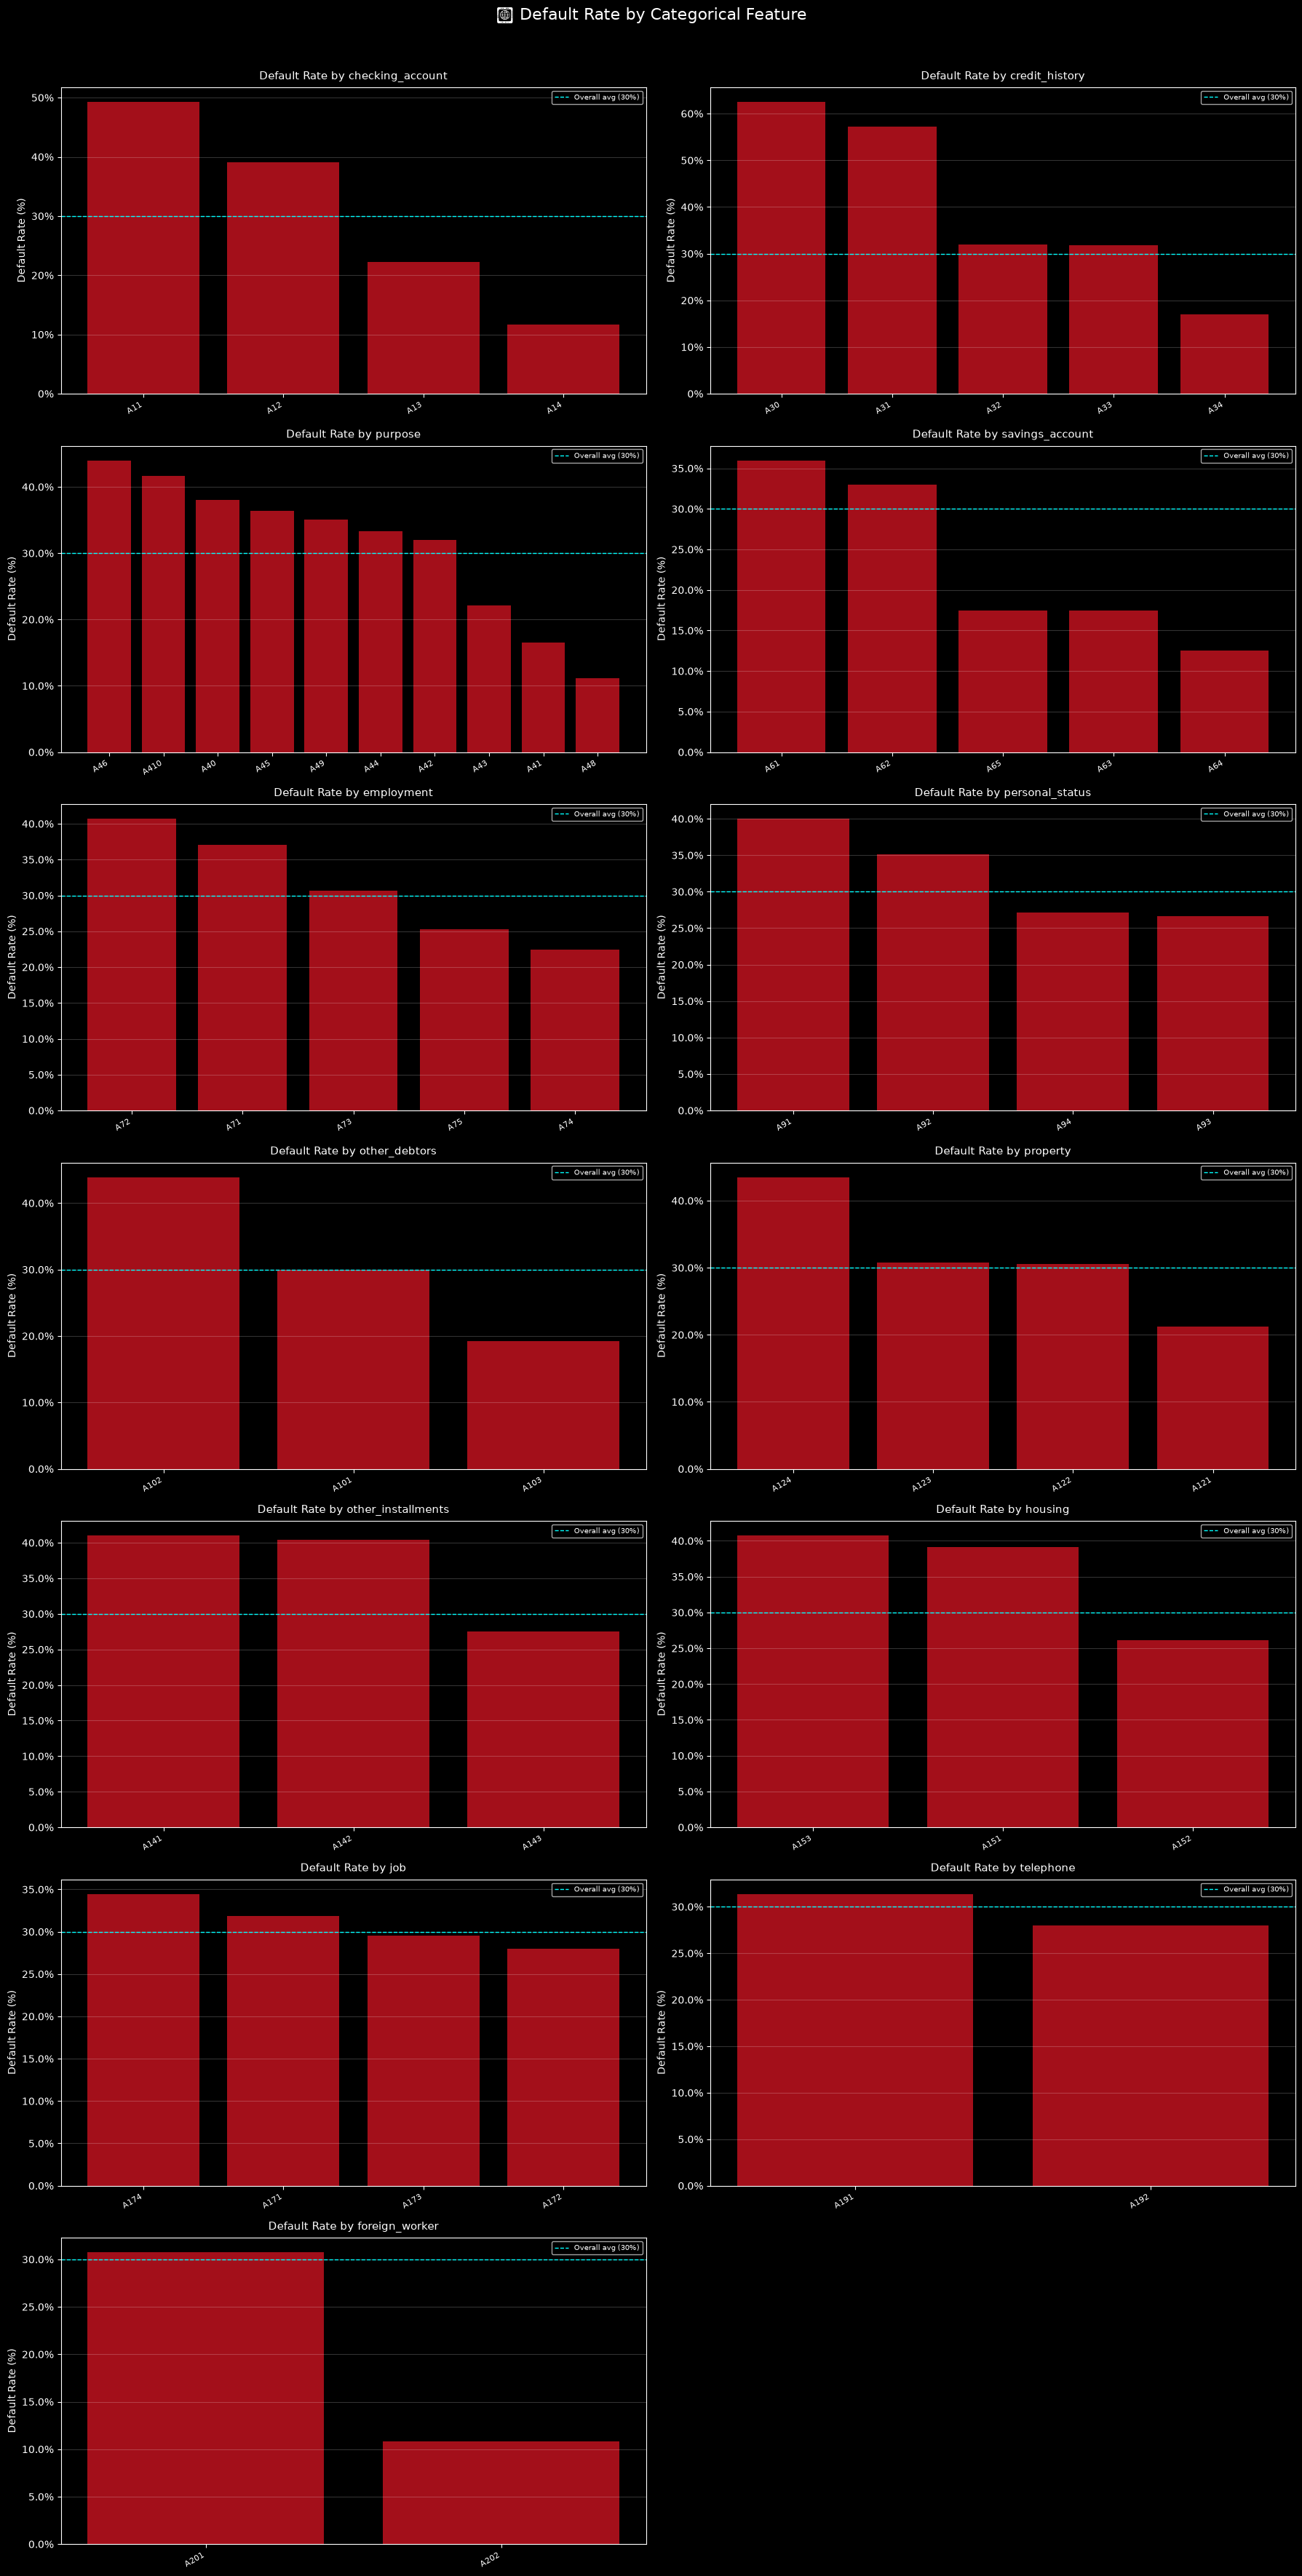

💾 Saved to ../figures/default_rate_by_category.png


In [7]:
categorical_cols = [
    "checking_account", "credit_history", "purpose", "savings_account",
    "employment", "personal_status", "other_debtors", "property",
    "other_installments", "housing", "job", "telephone", "foreign_worker"
]

n_cols = 2
n_rows = (len(categorical_cols) + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Compute default rate within each category
    # and sort from highest to lowest risk
    default_rate = df.groupby(col)["target"].mean() * 100
    default_rate = default_rate.sort_values(ascending=False)

    axes[i].bar(
        range(len(default_rate)),
        default_rate.values,
        color="#c1121f", alpha=0.85, edgecolor="none"
    )

    axes[i].set_xticks(range(len(default_rate)))
    axes[i].set_xticklabels(default_rate.index,
                             rotation=30, ha="right", fontsize=8)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].set_title(f"Default Rate by {col}", fontsize=11, pad=8)
    axes[i].set_ylabel("Default Rate (%)")
    axes[i].grid(alpha=0.2, axis="y")

    # Draw a dashed line at the overall average default rate
    axes[i].axhline(y=30, color="cyan", linestyle="--",
                    linewidth=1, label="Overall avg (30%)")
    axes[i].legend(fontsize=7)

# Hide any empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("📊 Default Rate by Categorical Feature",
             fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("../figures/default_rate_by_category.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved to ../figures/default_rate_by_category.png")

## 🔧 Section 4: Feature Engineering

### 📍 Step 1: One-Hot Encode Categorical Features

Machine learning models cannot process raw string values — they require
numerical inputs. We use one-hot encoding, which creates a binary (0/1)
column for each category. For example the checking_account column with
four categories becomes four binary columns — one per category.

We drop the first category of each feature (drop_first=True) to avoid
the dummy variable trap — where one column is perfectly predictable
from the others, creating redundant information that inflates the
model's apparent fit without adding genuine predictive power.

In [8]:
# Drop the temporary bin columns we created for visualisation
# so they don't appear as features in the model
df_encoded = pd.get_dummies(
    df.drop(columns=["age_bin", "duration_bin"]),
    columns=categorical_cols,
    drop_first=True
)

print(f"✅ One-hot encoding complete")
print(f"📐 Shape before encoding : {df.shape}")
print(f"📐 Shape after encoding  : {df_encoded.shape}")
print(f"📋 New columns added     : "
      f"{df_encoded.shape[1] - df.shape[1] + len(categorical_cols)}")

✅ One-hot encoding complete
📐 Shape before encoding : (1000, 23)
📐 Shape after encoding  : (1000, 49)
📋 New columns added     : 39


### 📍 Step 2: Scale Numerical Features

We standardise numerical features to have mean=0 and standard
deviation=1. The reason this matters is that logistic regression is
sensitive to feature scale — a feature measured in thousands
(credit_amount) would otherwise dominate a feature measured in single
digits (dependents), not because it is more predictive but simply
because its raw values are larger. Scaling puts every feature on equal
footing so coefficients reflect genuine predictive power rather than
units of measurement.

Note: XGBoost is tree-based and does not require scaling — but we
scale anyway so the same feature dataset works cleanly for both NB03
(logistic regression) and NB04 (XGBoost) without any additional
preprocessing.

In [9]:
scaler = StandardScaler()

# Fit and transform only the numerical columns
# The encoded binary columns do not need scaling
df_encoded[numerical_cols] = scaler.fit_transform(
    df_encoded[numerical_cols]
)

print("✅ Numerical features scaled to mean=0, std=1")
print(f"\n📊 Sample statistics after scaling:")
df_encoded[numerical_cols].describe().round(3)

✅ Numerical features scaled to mean=0, std=1

📊 Sample statistics after scaling:


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,dependents
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,0.000,0.000,0.000,-0.000,0.000,-0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-1.402,-1.071,-1.765,-1.672,-1.455,-0.705,-0.428
25%,-0.739,-0.675,-0.870,-0.766,-0.752,-0.705,-0.428
50%,-0.241,-0.337,0.024,0.141,-0.224,-0.705,-0.428
75%,0.257,0.248,0.918,1.047,0.568,1.027,-0.428
max,4.239,5.371,0.918,1.047,3.470,4.491,2.335


### 📍 Step 3: Final Feature Check

In [10]:
# Separate features (X) and target (y)
X = df_encoded.drop(columns=["target"])
y = df_encoded["target"]

print(f"✅ Feature matrix ready")
print(f"📐 X shape : {X.shape} — {X.shape[1]} features, "
      f"{X.shape[0]} observations")
print(f"🎯 y shape : {y.shape}")
print(f"⚖️  Class balance: {y.value_counts().to_dict()}")
print(f"\n📋 Feature names:")
print(X.columns.tolist())

✅ Feature matrix ready
📐 X shape : (1000, 48) — 48 features, 1000 observations
🎯 y shape : (1000,)
⚖️  Class balance: {0: 700, 1: 300}

📋 Feature names:
['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'dependents', 'checking_account_A12', 'checking_account_A13', 'checking_account_A14', 'credit_history_A31', 'credit_history_A32', 'credit_history_A33', 'credit_history_A34', 'purpose_A41', 'purpose_A410', 'purpose_A42', 'purpose_A43', 'purpose_A44', 'purpose_A45', 'purpose_A46', 'purpose_A48', 'purpose_A49', 'savings_account_A62', 'savings_account_A63', 'savings_account_A64', 'savings_account_A65', 'employment_A72', 'employment_A73', 'employment_A74', 'employment_A75', 'personal_status_A92', 'personal_status_A93', 'personal_status_A94', 'other_debtors_A102', 'other_debtors_A103', 'property_A122', 'property_A123', 'property_A124', 'other_installments_A142', 'other_installments_A143', 'housing_A152', 'housing_A153', 'job_A172', 'job_A173', 'jo

## 💾 Section 5: Save Engineered Features

### 📍 Export to CSV

In [11]:
FEATURES_PATH = "../data/processed/german_credit_features.csv"
df_encoded.to_csv(FEATURES_PATH, index=False)

print("✅ Files saved:")
print(f"   📄 {FEATURES_PATH}")
print(f"\n📐 Final shape : {df_encoded.shape}")
print(f"\n🚀 Ready for NB03 — Logistic Regression")

✅ Files saved:
   📄 ../data/processed/german_credit_features.csv

📐 Final shape : (1000, 49)

🚀 Ready for NB03 — Logistic Regression


## 🪞 Personal Reflection Notes — NB02

**🎯 Key Decisions Made in This Notebook**

The first decision was to use default rate by category rather than raw counts for the categorical analysis. Raw counts tell you how common a category is, not how risky it is — and risk is what we care about. A category with only 50 borrowers but a 60% default rate is far more informative for modelling than a category with 400 borrowers and a 28% default rate. By calculating default rate within each category and plotting it against the overall 30% average line, I could immediately identify which categories sit meaningfully above or below the baseline risk level.

The second decision was to bin age and duration into ranges rather than treating them as continuous variables in the default rate analysis. A simple correlation coefficient would only capture a linear relationship — but default risk might not decrease smoothly with age, it might drop sharply at a specific threshold. Binning reveals this non-linearity directly, which is important for framing the model comparison between logistic regression and XGBoost in NB03 and NB04.

The third decision was to use one-hot encoding with drop_first=True rather than label encoding for categorical features. Label encoding would assign arbitrary integers (0, 1, 2, 3) to categories, which implies an ordinal relationship that does not exist — a checking account category coded as 3 is not three times a category coded as 1. One-hot encoding avoids this by creating independent binary columns. Dropping the first category of each feature avoids the dummy variable trap where one column is perfectly predictable from the others, introducing redundancy that would inflate the model's apparent fit without adding genuine predictive power.

The fourth decision was to scale numerical features despite XGBoost not requiring it. The reason is consistency — NB03 and NB04 both load the same german_credit_features.csv, so scaling once here means neither notebook needs to handle it separately. The trade-off is a small loss of raw interpretability for the XGBoost model, but SHAP values in NB05 will restore interpretability regardless of scaling.

**📊 What the Charts Revealed**

The boxplots confirmed and sharpened the patterns observed in NB01. Duration showed the clearest separation — the median loan duration for defaulters was noticeably higher than for repaid borrowers, with the defaulted box sitting roughly 10 months higher. The defaulted distribution also had a wider spread and more outliers at the high end, suggesting that very long loans carry disproportionate default risk. Credit amount showed a similar but weaker pattern — the medians were closer together but defaulters had a longer upper tail. Age showed the opposite direction — repaid borrowers had a higher median age, with the repaid box centred around 35 versus roughly 30 for defaulters, consistent with older borrowers being more financially stable. Installment rate, residence since, existing credits, and dependents showed minimal separation between the two boxes — confirming they are weaker individual predictors.

The correlation heatmap revealed two important things. First, duration and credit amount are correlated at 0.62 — the strongest relationship in the matrix. This makes intuitive sense: larger loans typically require longer repayment periods. This moderate multicollinearity is worth monitoring in NB03 because logistic regression coefficients can become unstable when predictors are correlated. Second, both duration (0.21) and credit amount (0.15) show the strongest individual correlations with the target, confirming them as the most predictive numerical features. Notably, age shows a negative correlation with the target (-0.09) — older borrowers are less likely to default — which is consistent with the boxplot finding but the magnitude is small, suggesting age alone is a weak predictor.

The age default rate chart confirmed a strongly non-linear pattern. The 20-25 age group had a 42% default rate — nearly double the overall average of 30% — while the 36-40 group had just 21.7%. Interestingly, the 51+ group ticked back up to 27.4%, suggesting that very old borrowers face different risks compared to middle-aged borrowers — possibly fixed income constraints or retirement. This kind of non-linearity is exactly what XGBoost captures but logistic regression struggles with, which sets up the model comparison in NB04 as a meaningful test.

The duration default rate chart showed a near-monotonic increase from 21.2% for loans under 12 months to 52.1% for loans between 37-48 months, before a slight plateau at 50% for loans over 49 months. The jump from 25-36 months (39.9%) to 37-48 months (52.1%) is particularly sharp — a 12 percentage point increase — suggesting this is a critical risk threshold. A lender could use this directly as a policy rule: loans beyond 36 months warrant significantly more scrutiny or a higher interest rate to compensate for the elevated default risk.

The categorical default rate charts revealed the strongest signal in checking_account — borrowers with a negative balance (A11) had a default rate approaching 50%, while those with a balance over 200 DM (A14) had the lowest rate at around 15%. This is a direct proxy for current financial health and is likely to be the most important single feature in both models. Credit history also showed strong signal — borrowers with delayed or critical payment history had default rates approaching 60%, while those with all credits paid had rates well below average. These two features are likely to dominate the logistic regression coefficients in NB03 and the SHAP values in NB05.

**🔜 What This Sets Up for NB03**

The key findings to carry into NB03 are: duration and credit amount are the strongest numerical predictors but are moderately correlated with each other at 0.62, which warrants monitoring for multicollinearity in logistic regression. Checking account status and credit history are likely the strongest categorical predictors. Age has a non-linear relationship with default risk — the 42% rate in the 20-25 group versus 21.7% in the 36-40 group — that logistic regression will struggle to capture fully. This sets up the comparison with XGBoost in NB04 as the central analytical question of the project.